In [1]:
# Step 21: Set up inventory simulation notebook and load selected forecast data

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define project directories
current_dir = Path.cwd()
project_dir = current_dir.parent

tables_dir = project_dir / "outputs" / "tables"
figures_dir = project_dir / "outputs" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Load the selected forecast generated from the best forecasting model
selected_forecast_path = tables_dir / "selected_forecast_for_inventory_FOODS_3_586_TX_2.csv"

selected_forecast = pd.read_csv(selected_forecast_path)

# Convert date column to datetime format
selected_forecast["date"] = pd.to_datetime(selected_forecast["date"])

# Sort by date
selected_forecast = selected_forecast.sort_values("date").reset_index(drop=True)

print("Step 21 completed: Inventory simulation notebook setup finished.")

print("\nCurrent notebook directory:")
print(current_dir)

print("\nProject directory:")
print(project_dir)

print("\nSelected forecast path:")
print(selected_forecast_path)

print("\nSelected forecast shape:")
print(selected_forecast.shape)

print("\nDate range:")
print(selected_forecast["date"].min(), "to", selected_forecast["date"].max())

print("\nSelected forecast columns:")
print(selected_forecast.columns.tolist())

print("\nSelected forecast summary:")
display(selected_forecast[["actual_demand", "selected_forecast", "forecast_error", "absolute_error"]].describe())

print("\nFirst 10 rows:")
display(selected_forecast.head(10))

Step 21 completed: Inventory simulation notebook setup finished.

Current notebook directory:
/Users/mac/Desktop/portfolio1_demand_inventory/notebooks

Project directory:
/Users/mac/Desktop/portfolio1_demand_inventory

Selected forecast path:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/selected_forecast_for_inventory_FOODS_3_586_TX_2.csv

Selected forecast shape:
(56, 5)

Date range:
2016-03-28 00:00:00 to 2016-05-22 00:00:00

Selected forecast columns:
['date', 'actual_demand', 'selected_forecast', 'forecast_error', 'absolute_error']

Selected forecast summary:


,actual_demand,selected_forecast,forecast_error,absolute_error
count,56.000000,56.000000,56.000000,56.000000
mean,78.803571,77.916521,0.887051,9.836198
std,18.398043,17.095043,12.531076,7.701891
min,36.000000,60.525780,-29.665661,0.277336
25%,66.750000,63.923993,-4.981958,4.507695
50%,77.500000,68.853527,1.494289,7.237102
75%,88.250000,99.885156,9.882016,14.167530
max,119.000000,105.751198,24.377418,29.665661



First 10 rows:


,date,actual_demand,selected_forecast,forecast_error,absolute_error
0,2016-03-28,59,68.908215,-9.908215,9.908215
1,2016-03-29,51,65.065299,-14.065299,14.065299
2,2016-03-30,61,65.832442,-4.832442,4.832442
3,2016-03-31,79,72.246204,6.753796,6.753796
4,2016-04-01,77,81.545925,-4.545925,4.545925
5,2016-04-02,98,104.854560,-6.854560,6.854560
6,2016-04-03,107,100.060299,6.939701,6.939701
7,2016-04-04,68,64.668941,3.331059,3.331059
8,2016-04-05,74,60.826026,13.173974,13.173974
9,2016-04-06,72,61.593168,10.406832,10.406832


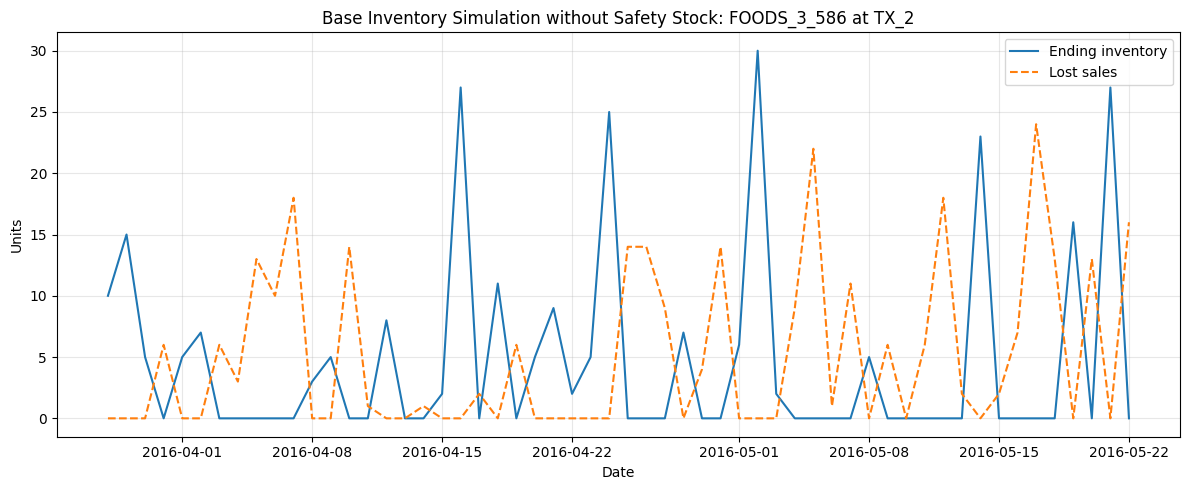

Step 22 completed: Base inventory policy simulation without safety stock.

Inventory policy assumptions:
Safety stock units: 0
Holding cost per unit per day: 1.0
Stockout cost per unit: 5.0

Base inventory policy summary:


,policy,safety_stock_units,holding_cost_per_unit_per_day,stockout_cost_per_unit,total_demand,total_order_quantity,total_fulfilled_demand,total_lost_sales,service_level,average_ending_inventory,total_holding_cost,total_stockout_cost,total_cost
0,Forecast-based order-up-to policy without safe...,0,1.0,5.0,4413,4128,4128,285,0.935418,4.642857,260.0,1425.0,1685.0



Base inventory simulation preview:


,date,actual_demand,selected_forecast,safety_stock_units,target_inventory,beginning_inventory,order_quantity,available_inventory,fulfilled_demand,lost_sales,ending_inventory,holding_cost,stockout_cost,total_cost
0,2016-03-28,59,68.908215,0,69,0,69,69,59,0,10,10.0,0.0,10.0
1,2016-03-29,51,65.065299,0,66,10,56,66,51,0,15,15.0,0.0,15.0
2,2016-03-30,61,65.832442,0,66,15,51,66,61,0,5,5.0,0.0,5.0
3,2016-03-31,79,72.246204,0,73,5,68,73,73,6,0,0.0,30.0,30.0
4,2016-04-01,77,81.545925,0,82,0,82,82,77,0,5,5.0,0.0,5.0
5,2016-04-02,98,104.854560,0,105,5,100,105,98,0,7,7.0,0.0,7.0
6,2016-04-03,107,100.060299,0,101,7,94,101,101,6,0,0.0,30.0,30.0
7,2016-04-04,68,64.668941,0,65,0,65,65,65,3,0,0.0,15.0,15.0
8,2016-04-05,74,60.826026,0,61,0,61,61,61,13,0,0.0,65.0,65.0
9,2016-04-06,72,61.593168,0,62,0,62,62,62,10,0,0.0,50.0,50.0



Validation checks:
Number of simulated days: 56
Total actual demand: 4413
Total fulfilled demand: 4128
Total lost sales: 285
Minimum ending inventory: 0

Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/base_inventory_simulation_no_safety_stock_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/base_inventory_policy_summary_no_safety_stock_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/base_inventory_simulation_no_safety_stock_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/base_inventory_simulation_no_safety_stock_FOODS_3_586_TX_2.pdf


In [2]:
# Step 22: Simulate a forecast-based inventory policy without safety stock

# Define inventory policy assumptions
safety_stock_units = 0
holding_cost_per_unit_per_day = 1.0
stockout_cost_per_unit = 5.0

# Define a reusable inventory simulation function
def simulate_inventory_policy(
    forecast_data,
    safety_stock_units,
    holding_cost_per_unit_per_day,
    stockout_cost_per_unit
):
    records = []
    
    current_inventory = 0
    
    for _, row in forecast_data.iterrows():
        date = row["date"]
        actual_demand = int(row["actual_demand"])
        selected_forecast = row["selected_forecast"]
        
        # Set the target inventory level based on forecast demand plus safety stock
        target_inventory = int(np.ceil(selected_forecast + safety_stock_units))
        
        # Beginning inventory is the inventory carried over from the previous day
        beginning_inventory = current_inventory
        
        # Order enough units to reach the target inventory level
        order_quantity = max(target_inventory - beginning_inventory, 0)
        
        # Assume replenishment arrives before daily demand occurs
        available_inventory = beginning_inventory + order_quantity
        
        # Fulfill as much demand as possible
        fulfilled_demand = min(available_inventory, actual_demand)
        lost_sales = max(actual_demand - available_inventory, 0)
        
        # Ending inventory after demand is fulfilled
        ending_inventory = available_inventory - fulfilled_demand
        
        # Calculate costs
        holding_cost = ending_inventory * holding_cost_per_unit_per_day
        stockout_cost = lost_sales * stockout_cost_per_unit
        total_cost = holding_cost + stockout_cost
        
        records.append({
            "date": date,
            "actual_demand": actual_demand,
            "selected_forecast": selected_forecast,
            "safety_stock_units": safety_stock_units,
            "target_inventory": target_inventory,
            "beginning_inventory": beginning_inventory,
            "order_quantity": order_quantity,
            "available_inventory": available_inventory,
            "fulfilled_demand": fulfilled_demand,
            "lost_sales": lost_sales,
            "ending_inventory": ending_inventory,
            "holding_cost": holding_cost,
            "stockout_cost": stockout_cost,
            "total_cost": total_cost
        })
        
        # Carry ending inventory to the next day
        current_inventory = ending_inventory
    
    simulation_results = pd.DataFrame(records)
    
    return simulation_results


# Run the base inventory simulation without safety stock
base_inventory_simulation = simulate_inventory_policy(
    forecast_data=selected_forecast,
    safety_stock_units=safety_stock_units,
    holding_cost_per_unit_per_day=holding_cost_per_unit_per_day,
    stockout_cost_per_unit=stockout_cost_per_unit
)

# Create a summary table for the base policy
base_policy_summary = pd.DataFrame({
    "policy": ["Forecast-based order-up-to policy without safety stock"],
    "safety_stock_units": [safety_stock_units],
    "holding_cost_per_unit_per_day": [holding_cost_per_unit_per_day],
    "stockout_cost_per_unit": [stockout_cost_per_unit],
    "total_demand": [base_inventory_simulation["actual_demand"].sum()],
    "total_order_quantity": [base_inventory_simulation["order_quantity"].sum()],
    "total_fulfilled_demand": [base_inventory_simulation["fulfilled_demand"].sum()],
    "total_lost_sales": [base_inventory_simulation["lost_sales"].sum()],
    "service_level": [
        base_inventory_simulation["fulfilled_demand"].sum()
        / base_inventory_simulation["actual_demand"].sum()
    ],
    "average_ending_inventory": [base_inventory_simulation["ending_inventory"].mean()],
    "total_holding_cost": [base_inventory_simulation["holding_cost"].sum()],
    "total_stockout_cost": [base_inventory_simulation["stockout_cost"].sum()],
    "total_cost": [base_inventory_simulation["total_cost"].sum()]
})

# Save simulation results and summary table
base_inventory_simulation_path = tables_dir / "base_inventory_simulation_no_safety_stock_FOODS_3_586_TX_2.csv"
base_policy_summary_path = tables_dir / "base_inventory_policy_summary_no_safety_stock_FOODS_3_586_TX_2.csv"

base_inventory_simulation.to_csv(base_inventory_simulation_path, index=False)
base_policy_summary.to_csv(base_policy_summary_path, index=False)


# ============================================================
# Plot: Inventory level and lost sales over time
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    base_inventory_simulation["date"],
    base_inventory_simulation["ending_inventory"],
    linewidth=1.5,
    label="Ending inventory"
)

plt.plot(
    base_inventory_simulation["date"],
    base_inventory_simulation["lost_sales"],
    linewidth=1.5,
    linestyle="--",
    label="Lost sales"
)

plt.title("Base Inventory Simulation without Safety Stock: FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

base_inventory_png_path = figures_dir / "base_inventory_simulation_no_safety_stock_FOODS_3_586_TX_2.png"
base_inventory_pdf_path = figures_dir / "base_inventory_simulation_no_safety_stock_FOODS_3_586_TX_2.pdf"

plt.savefig(base_inventory_png_path, dpi=300, bbox_inches="tight")
plt.savefig(base_inventory_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 22 completed: Base inventory policy simulation without safety stock.")

print("\nInventory policy assumptions:")
print("Safety stock units:", safety_stock_units)
print("Holding cost per unit per day:", holding_cost_per_unit_per_day)
print("Stockout cost per unit:", stockout_cost_per_unit)

print("\nBase inventory policy summary:")
display(base_policy_summary)

print("\nBase inventory simulation preview:")
display(base_inventory_simulation.head(10))

print("\nValidation checks:")
print("Number of simulated days:", len(base_inventory_simulation))
print("Total actual demand:", base_inventory_simulation["actual_demand"].sum())
print("Total fulfilled demand:", base_inventory_simulation["fulfilled_demand"].sum())
print("Total lost sales:", base_inventory_simulation["lost_sales"].sum())
print("Minimum ending inventory:", base_inventory_simulation["ending_inventory"].min())

print("\nTables saved to:")
print(base_inventory_simulation_path)
print(base_policy_summary_path)

print("\nFigures saved to:")
print(base_inventory_png_path)
print(base_inventory_pdf_path)

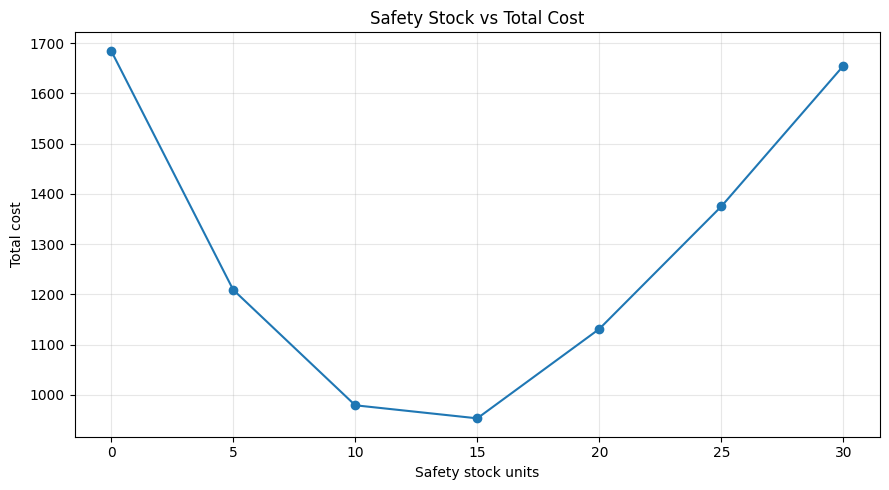

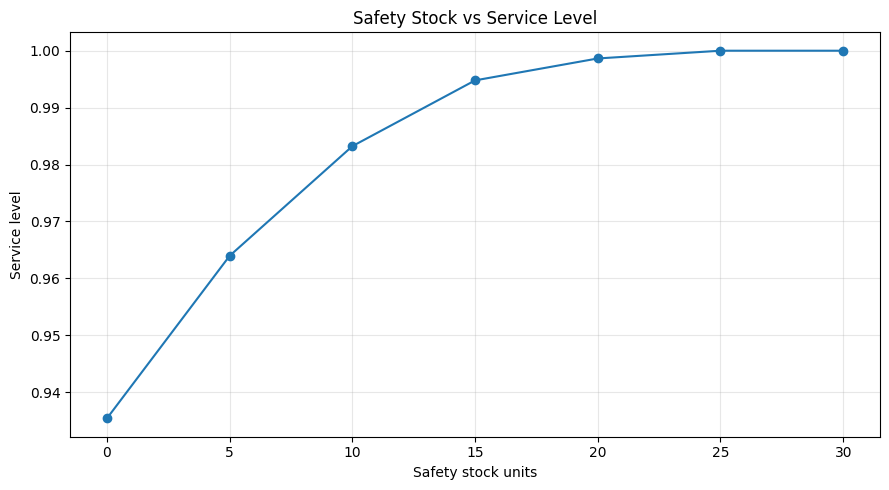

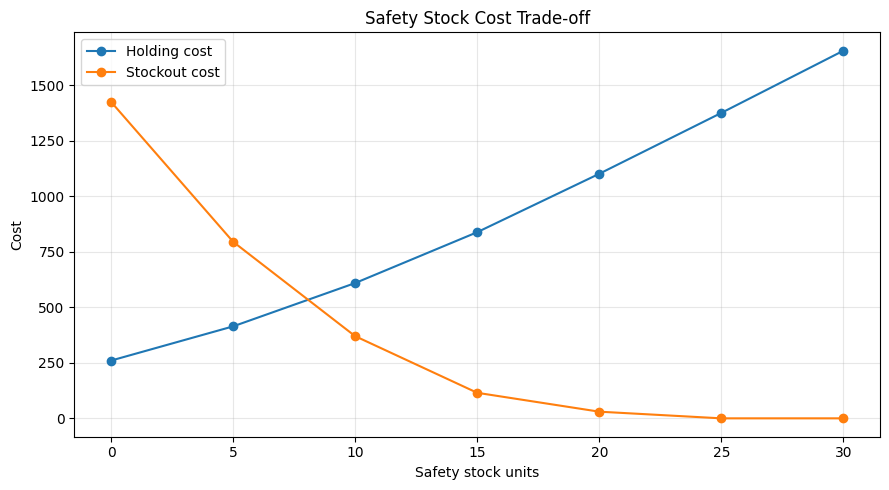

Step 23 completed: Safety stock policy comparison created.

Safety stock policy comparison:


,policy_label,safety_stock_units,total_demand,total_order_quantity,total_fulfilled_demand,total_lost_sales,service_level,average_ending_inventory,maximum_ending_inventory,stockout_days,total_holding_cost,total_stockout_cost,total_cost
0,Safety stock = 0,0,4413,4128,4128,285,0.935418,4.642857,30,30,260.0,1425.0,1685.0
1,Safety stock = 5,5,4413,4254,4254,159,0.963970,7.392857,35,22,414.0,795.0,1209.0
2,Safety stock = 10,10,4413,4339,4339,74,0.983231,10.875000,40,13,609.0,370.0,979.0
3,Safety stock = 15,15,4413,4390,4390,23,0.994788,14.964286,45,5,838.0,115.0,953.0
4,Safety stock = 20,20,4413,4411,4407,6,0.998640,19.660714,50,2,1101.0,30.0,1131.0
5,Safety stock = 25,25,4413,4422,4413,0,1.000000,24.553571,55,0,1375.0,0.0,1375.0
6,Safety stock = 30,30,4413,4427,4413,0,1.000000,29.553571,60,0,1655.0,0.0,1655.0



Best policy based on minimum total cost:


,policy_label,safety_stock_units,total_demand,total_order_quantity,total_fulfilled_demand,total_lost_sales,service_level,average_ending_inventory,maximum_ending_inventory,stockout_days,total_holding_cost,total_stockout_cost,total_cost
3,Safety stock = 15,15,4413,4390,4390,23,0.994788,14.964286,45,5,838.0,115.0,953.0



Best safety stock units:
15

Validation checks:
Number of policies tested: 7
Safety stock levels tested: [0, 5, 10, 15, 20, 25, 30]
Minimum total cost: 953.0
Maximum service level: 1.0

Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/safety_stock_policy_comparison_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/all_safety_stock_policy_simulations_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/safety_stock_vs_total_cost_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/safety_stock_vs_total_cost_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/safety_stock_vs_service_level_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/safety_stock_vs_service_level_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/safety_stock_cost_breakdown_FOO

In [3]:
# Step 23: Compare inventory policies with different safety stock levels

# Define safety stock levels to test
safety_stock_levels = [0, 5, 10, 15, 20, 25, 30]

# Store simulation summaries for each safety stock level
policy_summary_records = []
all_policy_simulations = []

for safety_stock in safety_stock_levels:
    # Run inventory simulation for this safety stock level
    simulation_result = simulate_inventory_policy(
        forecast_data=selected_forecast,
        safety_stock_units=safety_stock,
        holding_cost_per_unit_per_day=holding_cost_per_unit_per_day,
        stockout_cost_per_unit=stockout_cost_per_unit
    )
    
    # Add policy label
    simulation_result["policy_label"] = f"Safety stock = {safety_stock}"
    
    # Calculate summary metrics
    total_demand = simulation_result["actual_demand"].sum()
    total_fulfilled_demand = simulation_result["fulfilled_demand"].sum()
    total_lost_sales = simulation_result["lost_sales"].sum()
    service_level = total_fulfilled_demand / total_demand
    
    policy_summary_records.append({
        "policy_label": f"Safety stock = {safety_stock}",
        "safety_stock_units": safety_stock,
        "total_demand": total_demand,
        "total_order_quantity": simulation_result["order_quantity"].sum(),
        "total_fulfilled_demand": total_fulfilled_demand,
        "total_lost_sales": total_lost_sales,
        "service_level": service_level,
        "average_ending_inventory": simulation_result["ending_inventory"].mean(),
        "maximum_ending_inventory": simulation_result["ending_inventory"].max(),
        "stockout_days": (simulation_result["lost_sales"] > 0).sum(),
        "total_holding_cost": simulation_result["holding_cost"].sum(),
        "total_stockout_cost": simulation_result["stockout_cost"].sum(),
        "total_cost": simulation_result["total_cost"].sum()
    })
    
    all_policy_simulations.append(simulation_result)

# Create policy comparison table
safety_stock_policy_comparison = pd.DataFrame(policy_summary_records)

# Select the best policy based on minimum total cost
best_policy_row = safety_stock_policy_comparison.loc[
    safety_stock_policy_comparison["total_cost"].idxmin()
]

best_safety_stock_units = best_policy_row["safety_stock_units"]

# Combine all daily simulation results
all_policy_simulations = pd.concat(all_policy_simulations, ignore_index=True)

# Save policy comparison and all simulation results
safety_stock_policy_comparison_path = tables_dir / "safety_stock_policy_comparison_FOODS_3_586_TX_2.csv"
all_policy_simulations_path = tables_dir / "all_safety_stock_policy_simulations_FOODS_3_586_TX_2.csv"

safety_stock_policy_comparison.to_csv(safety_stock_policy_comparison_path, index=False)
all_policy_simulations.to_csv(all_policy_simulations_path, index=False)


# ============================================================
# Plot 1: Safety stock vs total cost
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    safety_stock_policy_comparison["safety_stock_units"],
    safety_stock_policy_comparison["total_cost"],
    marker="o",
    linewidth=1.5
)

plt.title("Safety Stock vs Total Cost")
plt.xlabel("Safety stock units")
plt.ylabel("Total cost")
plt.grid(True, alpha=0.3)
plt.tight_layout()

safety_stock_total_cost_png_path = figures_dir / "safety_stock_vs_total_cost_FOODS_3_586_TX_2.png"
safety_stock_total_cost_pdf_path = figures_dir / "safety_stock_vs_total_cost_FOODS_3_586_TX_2.pdf"

plt.savefig(safety_stock_total_cost_png_path, dpi=300, bbox_inches="tight")
plt.savefig(safety_stock_total_cost_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 2: Safety stock vs service level
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    safety_stock_policy_comparison["safety_stock_units"],
    safety_stock_policy_comparison["service_level"],
    marker="o",
    linewidth=1.5
)

plt.title("Safety Stock vs Service Level")
plt.xlabel("Safety stock units")
plt.ylabel("Service level")
plt.grid(True, alpha=0.3)
plt.tight_layout()

safety_stock_service_level_png_path = figures_dir / "safety_stock_vs_service_level_FOODS_3_586_TX_2.png"
safety_stock_service_level_pdf_path = figures_dir / "safety_stock_vs_service_level_FOODS_3_586_TX_2.pdf"

plt.savefig(safety_stock_service_level_png_path, dpi=300, bbox_inches="tight")
plt.savefig(safety_stock_service_level_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 3: Safety stock cost breakdown
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    safety_stock_policy_comparison["safety_stock_units"],
    safety_stock_policy_comparison["total_holding_cost"],
    marker="o",
    linewidth=1.5,
    label="Holding cost"
)

plt.plot(
    safety_stock_policy_comparison["safety_stock_units"],
    safety_stock_policy_comparison["total_stockout_cost"],
    marker="o",
    linewidth=1.5,
    label="Stockout cost"
)

plt.title("Safety Stock Cost Trade-off")
plt.xlabel("Safety stock units")
plt.ylabel("Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

safety_stock_cost_breakdown_png_path = figures_dir / "safety_stock_cost_breakdown_FOODS_3_586_TX_2.png"
safety_stock_cost_breakdown_pdf_path = figures_dir / "safety_stock_cost_breakdown_FOODS_3_586_TX_2.pdf"

plt.savefig(safety_stock_cost_breakdown_png_path, dpi=300, bbox_inches="tight")
plt.savefig(safety_stock_cost_breakdown_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 23 completed: Safety stock policy comparison created.")

print("\nSafety stock policy comparison:")
display(safety_stock_policy_comparison)

print("\nBest policy based on minimum total cost:")
display(best_policy_row.to_frame().T)

print("\nBest safety stock units:")
print(best_safety_stock_units)

print("\nValidation checks:")
print("Number of policies tested:", len(safety_stock_policy_comparison))
print("Safety stock levels tested:", safety_stock_policy_comparison["safety_stock_units"].tolist())
print("Minimum total cost:", safety_stock_policy_comparison["total_cost"].min())
print("Maximum service level:", safety_stock_policy_comparison["service_level"].max())

print("\nTables saved to:")
print(safety_stock_policy_comparison_path)
print(all_policy_simulations_path)

print("\nFigures saved to:")
print(safety_stock_total_cost_png_path)
print(safety_stock_total_cost_pdf_path)
print(safety_stock_service_level_png_path)
print(safety_stock_service_level_pdf_path)
print(safety_stock_cost_breakdown_png_path)
print(safety_stock_cost_breakdown_pdf_path)

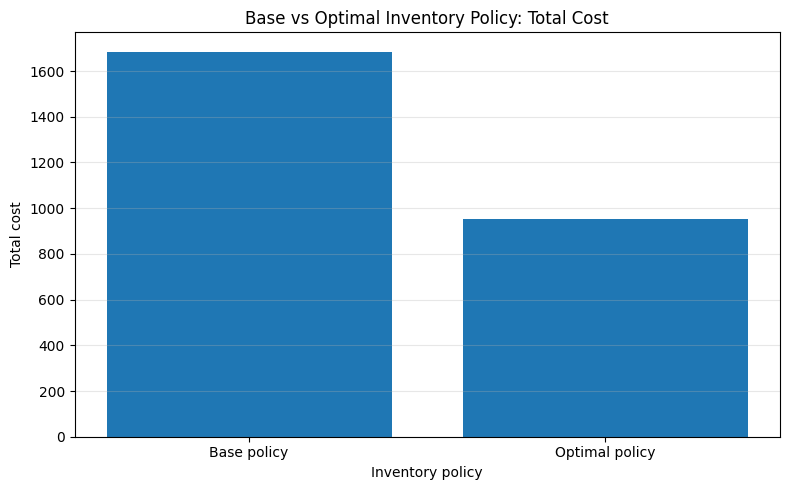

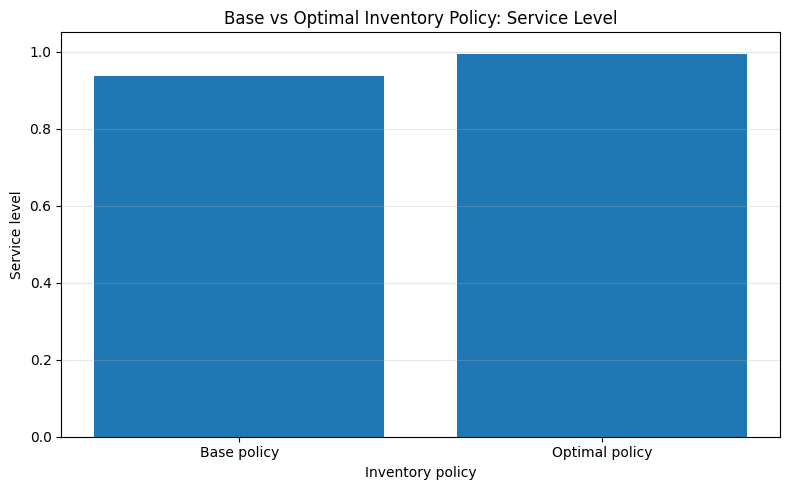

Step 24 completed: Final inventory policy recommendation created.

Base vs optimal inventory policy comparison:


,policy_type,safety_stock_units,total_lost_sales,service_level,stockout_days,average_ending_inventory,total_holding_cost,total_stockout_cost,total_cost
0,Base policy,0,285,0.935418,30,4.642857,260.0,1425.0,1685.0
1,Optimal policy,15,23,0.994788,5,14.964286,838.0,115.0,953.0



Final inventory policy recommendation:


,recommendation_metric,value
0,Recommended safety stock units,15.0000
1,Base policy total cost,1685.0000
2,Optimal policy total cost,953.0000
3,Total cost reduction,732.0000
4,Total cost reduction percent,43.4400
5,Base policy service level,0.9354
6,Optimal policy service level,0.9948
7,Service level improvement,0.0594
8,Lost sales reduction,262.0000
9,Stockout days reduction,25.0000



Recommended safety stock units:
15

Key improvement summary:
Lost sales reduction: 262
Stockout days reduction: 25
Service level improvement: 0.0594
Total cost reduction: 732.0
Total cost reduction percent: 43.44 %

Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/base_vs_optimal_inventory_policy_comparison_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/final_inventory_policy_recommendation_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/base_vs_optimal_total_cost_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/base_vs_optimal_total_cost_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/base_vs_optimal_service_level_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/base_vs_optimal_service_level_FOODS_3_586_TX_2.pdf


In [4]:
# Step 24: Create final inventory policy recommendation

# Identify base policy and optimal policy from the safety stock comparison table
base_policy_row = safety_stock_policy_comparison[
    safety_stock_policy_comparison["safety_stock_units"] == 0
].iloc[0]

optimal_policy_row = safety_stock_policy_comparison[
    safety_stock_policy_comparison["safety_stock_units"] == best_safety_stock_units
].iloc[0]

# Create a comparison table between base and optimal policies
base_vs_optimal_comparison = pd.DataFrame([
    {
        "policy_type": "Base policy",
        "safety_stock_units": base_policy_row["safety_stock_units"],
        "total_lost_sales": base_policy_row["total_lost_sales"],
        "service_level": base_policy_row["service_level"],
        "stockout_days": base_policy_row["stockout_days"],
        "average_ending_inventory": base_policy_row["average_ending_inventory"],
        "total_holding_cost": base_policy_row["total_holding_cost"],
        "total_stockout_cost": base_policy_row["total_stockout_cost"],
        "total_cost": base_policy_row["total_cost"]
    },
    {
        "policy_type": "Optimal policy",
        "safety_stock_units": optimal_policy_row["safety_stock_units"],
        "total_lost_sales": optimal_policy_row["total_lost_sales"],
        "service_level": optimal_policy_row["service_level"],
        "stockout_days": optimal_policy_row["stockout_days"],
        "average_ending_inventory": optimal_policy_row["average_ending_inventory"],
        "total_holding_cost": optimal_policy_row["total_holding_cost"],
        "total_stockout_cost": optimal_policy_row["total_stockout_cost"],
        "total_cost": optimal_policy_row["total_cost"]
    }
])

# Calculate improvement metrics
lost_sales_reduction = (
    base_policy_row["total_lost_sales"] - optimal_policy_row["total_lost_sales"]
)

stockout_days_reduction = (
    base_policy_row["stockout_days"] - optimal_policy_row["stockout_days"]
)

service_level_improvement = (
    optimal_policy_row["service_level"] - base_policy_row["service_level"]
)

total_cost_reduction = (
    base_policy_row["total_cost"] - optimal_policy_row["total_cost"]
)

total_cost_reduction_percent = (
    total_cost_reduction / base_policy_row["total_cost"] * 100
)

holding_cost_increase = (
    optimal_policy_row["total_holding_cost"] - base_policy_row["total_holding_cost"]
)

stockout_cost_reduction = (
    base_policy_row["total_stockout_cost"] - optimal_policy_row["total_stockout_cost"]
)

# Create final recommendation table
final_inventory_recommendation = pd.DataFrame({
    "recommendation_metric": [
        "Recommended safety stock units",
        "Base policy total cost",
        "Optimal policy total cost",
        "Total cost reduction",
        "Total cost reduction percent",
        "Base policy service level",
        "Optimal policy service level",
        "Service level improvement",
        "Lost sales reduction",
        "Stockout days reduction",
        "Holding cost increase",
        "Stockout cost reduction"
    ],
    "value": [
        best_safety_stock_units,
        base_policy_row["total_cost"],
        optimal_policy_row["total_cost"],
        total_cost_reduction,
        round(total_cost_reduction_percent, 2),
        round(base_policy_row["service_level"], 4),
        round(optimal_policy_row["service_level"], 4),
        round(service_level_improvement, 4),
        lost_sales_reduction,
        stockout_days_reduction,
        holding_cost_increase,
        stockout_cost_reduction
    ]
})

# Save final recommendation tables
base_vs_optimal_comparison_path = tables_dir / "base_vs_optimal_inventory_policy_comparison_FOODS_3_586_TX_2.csv"
final_inventory_recommendation_path = tables_dir / "final_inventory_policy_recommendation_FOODS_3_586_TX_2.csv"

base_vs_optimal_comparison.to_csv(base_vs_optimal_comparison_path, index=False)
final_inventory_recommendation.to_csv(final_inventory_recommendation_path, index=False)


# ============================================================
# Plot 1: Base vs optimal total cost
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    base_vs_optimal_comparison["policy_type"],
    base_vs_optimal_comparison["total_cost"]
)

plt.title("Base vs Optimal Inventory Policy: Total Cost")
plt.xlabel("Inventory policy")
plt.ylabel("Total cost")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

base_vs_optimal_cost_png_path = figures_dir / "base_vs_optimal_total_cost_FOODS_3_586_TX_2.png"
base_vs_optimal_cost_pdf_path = figures_dir / "base_vs_optimal_total_cost_FOODS_3_586_TX_2.pdf"

plt.savefig(base_vs_optimal_cost_png_path, dpi=300, bbox_inches="tight")
plt.savefig(base_vs_optimal_cost_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 2: Base vs optimal service level
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    base_vs_optimal_comparison["policy_type"],
    base_vs_optimal_comparison["service_level"]
)

plt.title("Base vs Optimal Inventory Policy: Service Level")
plt.xlabel("Inventory policy")
plt.ylabel("Service level")
plt.ylim(0, 1.05)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

base_vs_optimal_service_png_path = figures_dir / "base_vs_optimal_service_level_FOODS_3_586_TX_2.png"
base_vs_optimal_service_pdf_path = figures_dir / "base_vs_optimal_service_level_FOODS_3_586_TX_2.pdf"

plt.savefig(base_vs_optimal_service_png_path, dpi=300, bbox_inches="tight")
plt.savefig(base_vs_optimal_service_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 24 completed: Final inventory policy recommendation created.")

print("\nBase vs optimal inventory policy comparison:")
display(base_vs_optimal_comparison)

print("\nFinal inventory policy recommendation:")
display(final_inventory_recommendation)

print("\nRecommended safety stock units:")
print(best_safety_stock_units)

print("\nKey improvement summary:")
print("Lost sales reduction:", lost_sales_reduction)
print("Stockout days reduction:", stockout_days_reduction)
print("Service level improvement:", round(service_level_improvement, 4))
print("Total cost reduction:", total_cost_reduction)
print("Total cost reduction percent:", round(total_cost_reduction_percent, 2), "%")

print("\nTables saved to:")
print(base_vs_optimal_comparison_path)
print(final_inventory_recommendation_path)

print("\nFigures saved to:")
print(base_vs_optimal_cost_png_path)
print(base_vs_optimal_cost_pdf_path)
print(base_vs_optimal_service_png_path)
print(base_vs_optimal_service_pdf_path)

In [5]:
# Step 25: Create final project summary table

# Define report directory
report_dir = project_dir / "report"
report_dir.mkdir(parents=True, exist_ok=True)

# Load final forecasting results from Step 20
forecast_model_comparison_path = tables_dir / "final_model_comparison_metrics_FOODS_3_586_TX_2.csv"
forecast_model_comparison = pd.read_csv(forecast_model_comparison_path)

# Load final inventory recommendation from Step 24
final_inventory_recommendation_path = tables_dir / "final_inventory_policy_recommendation_FOODS_3_586_TX_2.csv"
base_vs_optimal_comparison_path = tables_dir / "base_vs_optimal_inventory_policy_comparison_FOODS_3_586_TX_2.csv"

final_inventory_recommendation_loaded = pd.read_csv(final_inventory_recommendation_path)
base_vs_optimal_comparison_loaded = pd.read_csv(base_vs_optimal_comparison_path)

# Identify best forecasting model
best_forecast_model = forecast_model_comparison.sort_values("MAE").iloc[0]

# Identify naive forecast model for comparison
naive_forecast_model = forecast_model_comparison[
    forecast_model_comparison["model"] == "Naive forecast"
].iloc[0]

# Calculate forecast improvement from naive baseline
mae_reduction_from_naive = naive_forecast_model["MAE"] - best_forecast_model["MAE"]
mae_reduction_percent_from_naive = (
    mae_reduction_from_naive / naive_forecast_model["MAE"] * 100
)

# Helper function to extract values from the recommendation table
def get_recommendation_value(metric_name):
    return final_inventory_recommendation_loaded.loc[
        final_inventory_recommendation_loaded["recommendation_metric"] == metric_name,
        "value"
    ].iloc[0]

# Extract final inventory recommendation values
recommended_safety_stock = get_recommendation_value("Recommended safety stock units")
base_policy_total_cost = get_recommendation_value("Base policy total cost")
optimal_policy_total_cost = get_recommendation_value("Optimal policy total cost")
total_cost_reduction = get_recommendation_value("Total cost reduction")
total_cost_reduction_percent = get_recommendation_value("Total cost reduction percent")
base_policy_service_level = get_recommendation_value("Base policy service level")
optimal_policy_service_level = get_recommendation_value("Optimal policy service level")
service_level_improvement = get_recommendation_value("Service level improvement")
lost_sales_reduction = get_recommendation_value("Lost sales reduction")
stockout_days_reduction = get_recommendation_value("Stockout days reduction")

# Create final project summary table
final_project_summary = pd.DataFrame({
    "section": [
        "Project scope",
        "Project scope",
        "Forecasting",
        "Forecasting",
        "Forecasting",
        "Forecasting",
        "Forecasting",
        "Inventory policy",
        "Inventory policy",
        "Inventory policy",
        "Inventory policy",
        "Inventory policy",
        "Inventory policy",
        "Inventory policy"
    ],
    "metric": [
        "Selected item-store",
        "Forecast horizon",
        "Best forecasting model",
        "Best model MAE",
        "Best model RMSE",
        "Best model MAPE (%)",
        "MAE reduction from naive baseline (%)",
        "Recommended safety stock units",
        "Base policy total cost",
        "Optimal policy total cost",
        "Total cost reduction",
        "Total cost reduction percent",
        "Service level improvement",
        "Lost sales reduction"
    ],
    "value": [
        "FOODS_3_586 at TX_2",
        "56 days",
        best_forecast_model["model"],
        round(best_forecast_model["MAE"], 2),
        round(best_forecast_model["RMSE"], 2),
        round(best_forecast_model["MAPE_percent"], 2),
        round(mae_reduction_percent_from_naive, 2),
        int(recommended_safety_stock),
        round(base_policy_total_cost, 2),
        round(optimal_policy_total_cost, 2),
        round(total_cost_reduction, 2),
        round(total_cost_reduction_percent, 2),
        round(service_level_improvement, 4),
        int(lost_sales_reduction)
    ]
})

# Save final project summary table
final_project_summary_path = tables_dir / "final_project_summary_FOODS_3_586_TX_2.csv"
final_project_summary.to_csv(final_project_summary_path, index=False)

# Create a Markdown summary for the report folder
markdown_summary_path = report_dir / "final_project_summary_FOODS_3_586_TX_2.md"

markdown_text = f"""# Final Project Summary: Demand Forecasting and Inventory Policy Simulation

## Project Scope

- Selected item-store: FOODS_3_586 at TX_2
- Forecast horizon: 56 days
- Main workflow: demand forecasting followed by inventory policy simulation

## Forecasting Result

The best forecasting model was **{best_forecast_model["model"]}**.

- MAE: {best_forecast_model["MAE"]:.2f}
- RMSE: {best_forecast_model["RMSE"]:.2f}
- MAPE: {best_forecast_model["MAPE_percent"]:.2f}%
- MAE reduction from naive baseline: {mae_reduction_percent_from_naive:.2f}%

## Inventory Policy Recommendation

The recommended safety stock level was **{int(recommended_safety_stock)} units**.

Compared with the base policy without safety stock:

- Total cost decreased from {base_policy_total_cost:.2f} to {optimal_policy_total_cost:.2f}
- Total cost reduction: {total_cost_reduction:.2f} ({total_cost_reduction_percent:.2f}%)
- Service level improved from {base_policy_service_level:.4f} to {optimal_policy_service_level:.4f}
- Lost sales decreased by {int(lost_sales_reduction)} units
- Stockout days decreased by {int(stockout_days_reduction)} days

## Interpretation

The results suggest that combining calendar-feature demand forecasting with a safety-stock-based replenishment policy can reduce stockout risk while lowering total inventory-related cost.
"""

with open(markdown_summary_path, "w") as file:
    file.write(markdown_text)

print("Step 25 completed: Final project summary table created.")

print("\nFinal project summary:")
display(final_project_summary)

print("\nBest forecasting model:")
print(best_forecast_model["model"])

print("\nRecommended safety stock units:")
print(int(recommended_safety_stock))

print("\nKey final results:")
print("Best model MAE:", round(best_forecast_model["MAE"], 2))
print("Best model MAPE (%):", round(best_forecast_model["MAPE_percent"], 2))
print("Total cost reduction:", round(total_cost_reduction, 2))
print("Total cost reduction percent:", round(total_cost_reduction_percent, 2), "%")
print("Lost sales reduction:", int(lost_sales_reduction))

print("\nFiles saved to:")
print(final_project_summary_path)
print(markdown_summary_path)

Step 25 completed: Final project summary table created.

Final project summary:


,section,metric,value
0,Project scope,Selected item-store,FOODS_3_586 at TX_2
1,Project scope,Forecast horizon,56 days
2,Forecasting,Best forecasting model,Calendar-feature linear regression forecast
3,Forecasting,Best model MAE,9.84
4,Forecasting,Best model RMSE,12.45
5,Forecasting,Best model MAPE (%),13.45
6,Forecasting,MAE reduction from naive baseline (%),59.05
7,Inventory policy,Recommended safety stock units,15
8,Inventory policy,Base policy total cost,1685.0
9,Inventory policy,Optimal policy total cost,953.0



Best forecasting model:
Calendar-feature linear regression forecast

Recommended safety stock units:
15

Key final results:
Best model MAE: 9.84
Best model MAPE (%): 13.45
Total cost reduction: 732.0
Total cost reduction percent: 43.44 %
Lost sales reduction: 262

Files saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/final_project_summary_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/report/final_project_summary_FOODS_3_586_TX_2.md


In [6]:
# Step 26: Create final output inventory and project file checklist

# Define important project files to check
expected_files = [
    # Notebooks
    {
        "category": "Notebook",
        "relative_path": "notebooks/01_data_preparation.ipynb"
    },
    {
        "category": "Notebook",
        "relative_path": "notebooks/02_exploratory_analysis.ipynb"
    },
    {
        "category": "Notebook",
        "relative_path": "notebooks/03_demand_forecasting.ipynb"
    },
    {
        "category": "Notebook",
        "relative_path": "notebooks/04_inventory_policy_simulation.ipynb"
    },

    # Processed data
    {
        "category": "Processed data",
        "relative_path": "data/processed/daily_demand_FOODS_3_586_TX_2.csv"
    },

    # Final forecasting outputs
    {
        "category": "Forecasting table",
        "relative_path": "outputs/tables/final_model_comparison_metrics_FOODS_3_586_TX_2.csv"
    },
    {
        "category": "Forecasting table",
        "relative_path": "outputs/tables/selected_forecast_for_inventory_FOODS_3_586_TX_2.csv"
    },
    {
        "category": "Forecasting figure",
        "relative_path": "outputs/figures/forecast_model_comparison_MAE_FOODS_3_586_TX_2.png"
    },
    {
        "category": "Forecasting figure",
        "relative_path": "outputs/figures/forecast_model_comparison_RMSE_FOODS_3_586_TX_2.png"
    },
    {
        "category": "Forecasting figure",
        "relative_path": "outputs/figures/forecast_model_comparison_MAPE_FOODS_3_586_TX_2.png"
    },

    # Final inventory outputs
    {
        "category": "Inventory table",
        "relative_path": "outputs/tables/safety_stock_policy_comparison_FOODS_3_586_TX_2.csv"
    },
    {
        "category": "Inventory table",
        "relative_path": "outputs/tables/base_vs_optimal_inventory_policy_comparison_FOODS_3_586_TX_2.csv"
    },
    {
        "category": "Inventory table",
        "relative_path": "outputs/tables/final_inventory_policy_recommendation_FOODS_3_586_TX_2.csv"
    },
    {
        "category": "Inventory figure",
        "relative_path": "outputs/figures/safety_stock_vs_total_cost_FOODS_3_586_TX_2.png"
    },
    {
        "category": "Inventory figure",
        "relative_path": "outputs/figures/safety_stock_vs_service_level_FOODS_3_586_TX_2.png"
    },
    {
        "category": "Inventory figure",
        "relative_path": "outputs/figures/safety_stock_cost_breakdown_FOODS_3_586_TX_2.png"
    },
    {
        "category": "Inventory figure",
        "relative_path": "outputs/figures/base_vs_optimal_total_cost_FOODS_3_586_TX_2.png"
    },
    {
        "category": "Inventory figure",
        "relative_path": "outputs/figures/base_vs_optimal_service_level_FOODS_3_586_TX_2.png"
    },

    # Final project summary
    {
        "category": "Final summary",
        "relative_path": "outputs/tables/final_project_summary_FOODS_3_586_TX_2.csv"
    },
    {
        "category": "Final summary",
        "relative_path": "report/final_project_summary_FOODS_3_586_TX_2.md"
    }
]

# Create output inventory records
inventory_records = []

for file_info in expected_files:
    relative_path = file_info["relative_path"]
    absolute_path = project_dir / relative_path
    
    file_exists = absolute_path.exists()
    
    if file_exists:
        file_size_kb = round(absolute_path.stat().st_size / 1024, 2)
    else:
        file_size_kb = np.nan
    
    inventory_records.append({
        "category": file_info["category"],
        "file_name": absolute_path.name,
        "relative_path": relative_path,
        "exists": file_exists,
        "file_size_kb": file_size_kb
    })

# Create output inventory table
project_output_inventory = pd.DataFrame(inventory_records)

# Save output inventory table
project_output_inventory_path = tables_dir / "project_output_inventory_FOODS_3_586_TX_2.csv"
project_output_inventory.to_csv(project_output_inventory_path, index=False)

# Summarize missing files
missing_files = project_output_inventory[
    project_output_inventory["exists"] == False
]

print("Step 26 completed: Final project output inventory created.")

print("\nProject output inventory:")
display(project_output_inventory)

print("\nOutput inventory summary:")
print("Total expected files:", len(project_output_inventory))
print("Existing files:", project_output_inventory["exists"].sum())
print("Missing files:", len(missing_files))

print("\nMissing files, if any:")
display(missing_files)

print("\nOutput inventory saved to:")
print(project_output_inventory_path)

Step 26 completed: Final project output inventory created.

Project output inventory:


,category,file_name,relative_path,exists,file_size_kb
0,Notebook,01_data_preparation.ipynb,notebooks/01_data_preparation.ipynb,True,99.96
1,Notebook,02_exploratory_analysis.ipynb,notebooks/02_exploratory_analysis.ipynb,True,585.35
2,Notebook,03_demand_forecasting.ipynb,notebooks/03_demand_forecasting.ipynb,True,672.46
3,Notebook,04_inventory_policy_simulation.ipynb,notebooks/04_inventory_policy_simulation.ipynb,True,454.02
4,Processed data,daily_demand_FOODS_3_586_TX_2.csv,data/processed/daily_demand_FOODS_3_586_TX_2.csv,True,229.27
5,Forecasting table,final_model_comparison_metrics_FOODS_3_586_TX_...,outputs/tables/final_model_comparison_metrics_...,True,0.65
6,Forecasting table,selected_forecast_for_inventory_FOODS_3_586_TX...,outputs/tables/selected_forecast_for_inventory...,True,3.89
7,Forecasting figure,forecast_model_comparison_MAE_FOODS_3_586_TX_2...,outputs/figures/forecast_model_comparison_MAE_...,True,117.75
8,Forecasting figure,forecast_model_comparison_RMSE_FOODS_3_586_TX_...,outputs/figures/forecast_model_comparison_RMSE...,True,119.66
9,Forecasting figure,forecast_model_comparison_MAPE_FOODS_3_586_TX_...,outputs/figures/forecast_model_comparison_MAPE...,True,126.78



Output inventory summary:
Total expected files: 20
Existing files: 20
Missing files: 0

Missing files, if any:


,category,file_name,relative_path,exists,file_size_kb



Output inventory saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/project_output_inventory_FOODS_3_586_TX_2.csv


In [7]:
# Step 27: Create project README file

# Load final project summary
final_project_summary_path = tables_dir / "final_project_summary_FOODS_3_586_TX_2.csv"
final_project_summary = pd.read_csv(final_project_summary_path)

# Helper function to extract values from final project summary
def get_summary_value(metric_name):
    return final_project_summary.loc[
        final_project_summary["metric"] == metric_name,
        "value"
    ].iloc[0]

# Extract key project results
selected_item_store = get_summary_value("Selected item-store")
forecast_horizon = get_summary_value("Forecast horizon")
best_forecasting_model = get_summary_value("Best forecasting model")
best_model_mae = get_summary_value("Best model MAE")
best_model_rmse = get_summary_value("Best model RMSE")
best_model_mape = get_summary_value("Best model MAPE (%)")
mae_reduction_from_naive = get_summary_value("MAE reduction from naive baseline (%)")
recommended_safety_stock = get_summary_value("Recommended safety stock units")
base_policy_total_cost = get_summary_value("Base policy total cost")
optimal_policy_total_cost = get_summary_value("Optimal policy total cost")
total_cost_reduction = get_summary_value("Total cost reduction")
total_cost_reduction_percent = get_summary_value("Total cost reduction percent")
service_level_improvement = get_summary_value("Service level improvement")
lost_sales_reduction = get_summary_value("Lost sales reduction")

# Create README content using a list of text lines
readme_lines = [
    "# Demand Forecasting and Inventory Policy Simulation",
    "",
    "## Project Overview",
    "",
    "This project analyzes how demand forecasting can be connected with inventory replenishment decisions for a retail product-store combination.",
    "",
    "The main research question is:",
    "",
    "**How can demand forecasting be integrated with inventory policies to improve replenishment decisions under demand uncertainty?**",
    "",
    "The project follows a practical operations analytics workflow:",
    "",
    "1. Prepare item-store level daily demand data",
    "2. Explore demand patterns",
    "3. Build and compare forecasting models",
    "4. Select the best demand forecast",
    "5. Simulate inventory replenishment policies",
    "6. Recommend a safety stock level based on total cost and service level",
    "",
    "## Dataset",
    "",
    "The project uses the M5 Forecasting dataset.",
    "",
    "Selected item-store combination:",
    "",
    f"- **{selected_item_store}**",
    f"- Forecast horizon: **{forecast_horizon}**",
    "",
    "The processed dataset contains daily demand, selling price, calendar variables, and revenue-related fields for the selected item-store pair.",
    "",
    "## Methodology",
    "",
    "### 1. Data Preparation",
    "",
    "The raw M5 data was transformed from wide daily sales format into a clean daily time-series dataset for one item-store combination.",
    "",
    "### 2. Exploratory Data Analysis",
    "",
    "The exploratory analysis examined:",
    "",
    "- Historical demand trend",
    "- Demand distribution and outliers",
    "- Weekday demand patterns",
    "- Monthly demand patterns",
    "- Price-demand patterns",
    "- Yearly demand and price trends",
    "",
    "### 3. Demand Forecasting",
    "",
    "Several forecasting approaches were compared:",
    "",
    "- Naive forecast",
    "- 7-day moving average forecast",
    "- 28-day moving average forecast",
    "- Weekday-adjusted moving average forecast",
    "- Calendar-feature linear regression forecast",
    "",
    "The best forecasting model was:",
    "",
    f"**{best_forecasting_model}**",
    "",
    "Forecasting performance:",
    "",
    f"- MAE: **{best_model_mae}**",
    f"- RMSE: **{best_model_rmse}**",
    f"- MAPE: **{best_model_mape}%**",
    f"- MAE reduction from naive baseline: **{mae_reduction_from_naive}%**",
    "",
    "### 4. Inventory Policy Simulation",
    "",
    "The selected forecast was used as an input to simulate forecast-based replenishment policies.",
    "",
    "The inventory policy tested different safety stock levels:",
    "",
    "- 0 units",
    "- 5 units",
    "- 10 units",
    "- 15 units",
    "- 20 units",
    "- 25 units",
    "- 30 units",
    "",
    "The simulation evaluated each policy using:",
    "",
    "- Total lost sales",
    "- Service level",
    "- Stockout days",
    "- Average ending inventory",
    "- Holding cost",
    "- Stockout cost",
    "- Total cost",
    "",
    "## Key Results",
    "",
    "The recommended safety stock level was:",
    "",
    f"**{recommended_safety_stock} units**",
    "",
    "Compared with the base policy without safety stock:",
    "",
    f"- Total cost decreased from **{base_policy_total_cost}** to **{optimal_policy_total_cost}**",
    f"- Total cost reduction: **{total_cost_reduction}**",
    f"- Total cost reduction percent: **{total_cost_reduction_percent}%**",
    f"- Service level improvement: **{service_level_improvement}**",
    f"- Lost sales reduction: **{lost_sales_reduction} units**",
    "",
    "## Repository Structure",
    "",
    "```text",
    "portfolio1_demand_inventory/",
    "├── data/",
    "│   ├── raw/",
    "│   └── processed/",
    "├── notebooks/",
    "│   ├── 01_data_preparation.ipynb",
    "│   ├── 02_exploratory_analysis.ipynb",
    "│   ├── 03_demand_forecasting.ipynb",
    "│   └── 04_inventory_policy_simulation.ipynb",
    "├── outputs/",
    "│   ├── figures/",
    "│   └── tables/",
    "├── report/",
    "└── README.md",
    "```",
    "",
    "## Key Output Files",
    "",
    "Important tables:",
    "",
    "- `outputs/tables/final_model_comparison_metrics_FOODS_3_586_TX_2.csv`",
    "- `outputs/tables/selected_forecast_for_inventory_FOODS_3_586_TX_2.csv`",
    "- `outputs/tables/safety_stock_policy_comparison_FOODS_3_586_TX_2.csv`",
    "- `outputs/tables/final_inventory_policy_recommendation_FOODS_3_586_TX_2.csv`",
    "- `outputs/tables/final_project_summary_FOODS_3_586_TX_2.csv`",
    "",
    "Important figures:",
    "",
    "- `outputs/figures/forecast_model_comparison_MAE_FOODS_3_586_TX_2.png`",
    "- `outputs/figures/forecast_model_comparison_RMSE_FOODS_3_586_TX_2.png`",
    "- `outputs/figures/forecast_model_comparison_MAPE_FOODS_3_586_TX_2.png`",
    "- `outputs/figures/safety_stock_vs_total_cost_FOODS_3_586_TX_2.png`",
    "- `outputs/figures/safety_stock_vs_service_level_FOODS_3_586_TX_2.png`",
    "- `outputs/figures/safety_stock_cost_breakdown_FOODS_3_586_TX_2.png`",
    "- `outputs/figures/base_vs_optimal_total_cost_FOODS_3_586_TX_2.png`",
    "- `outputs/figures/base_vs_optimal_service_level_FOODS_3_586_TX_2.png`",
    "",
    "## Interpretation",
    "",
    "The results show that a calendar-feature forecasting model improved short-term demand forecasting accuracy compared with simple baseline models.",
    "",
    f"The inventory simulation further showed that adding safety stock can reduce stockout risk and total cost. In this case, a safety stock level of **{recommended_safety_stock} units** achieved the lowest total cost among the tested policies.",
    "",
    "## Limitations",
    "",
    "This project focuses on one item-store combination. The results should be interpreted as a case study rather than a universal policy for all products or stores.",
    "",
    "The inventory simulation uses simplified assumptions, including:",
    "",
    "- Daily replenishment",
    "- Immediate replenishment before demand occurs",
    "- Fixed holding cost",
    "- Fixed stockout cost",
    "- No supplier lead time uncertainty",
    "",
    "Future extensions could test multiple item-store pairs, include lead time, compare additional forecasting models, and evaluate more advanced replenishment policies.",
    "",
    "## Tools Used",
    "",
    "- Python",
    "- pandas",
    "- NumPy",
    "- matplotlib",
    "- scikit-learn",
    "- Jupyter Notebook",
    "",
    "## Project Summary",
    "",
    "This project demonstrates an end-to-end operations analytics workflow that connects demand forecasting with inventory replenishment decisions.",
    ""
]

# Combine lines into one README text
readme_text = "\n".join(readme_lines)

# Save README file to project root
readme_path = project_dir / "README.md"

with open(readme_path, "w") as file:
    file.write(readme_text)

print("Step 27 completed: Project README file created.")

print("\nREADME saved to:")
print(readme_path)

print("\nREADME file exists:")
print(readme_path.exists())

print("\nREADME file size in KB:")
print(round(readme_path.stat().st_size / 1024, 2))

print("\nREADME preview:")
print(readme_text[:1500])

Step 27 completed: Project README file created.

README saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/README.md

README file exists:
True

README file size in KB:
5.13

README preview:
# Demand Forecasting and Inventory Policy Simulation

## Project Overview

This project analyzes how demand forecasting can be connected with inventory replenishment decisions for a retail product-store combination.

The main research question is:

**How can demand forecasting be integrated with inventory policies to improve replenishment decisions under demand uncertainty?**

The project follows a practical operations analytics workflow:

1. Prepare item-store level daily demand data
2. Explore demand patterns
3. Build and compare forecasting models
4. Select the best demand forecast
5. Simulate inventory replenishment policies
6. Recommend a safety stock level based on total cost and service level

## Dataset

The project uses the M5 Forecasting dataset.

Selected item-store combination:

- 

In [8]:
# Step 28: Create requirements file and environment summary

import sys
import pandas as pd
import numpy as np
import matplotlib
import sklearn

# Define package versions used in this project
environment_records = [
    {
        "component": "Python",
        "version": sys.version.split()[0]
    },
    {
        "component": "pandas",
        "version": pd.__version__
    },
    {
        "component": "numpy",
        "version": np.__version__
    },
    {
        "component": "matplotlib",
        "version": matplotlib.__version__
    },
    {
        "component": "scikit-learn",
        "version": sklearn.__version__
    }
]

environment_summary = pd.DataFrame(environment_records)

# Save environment summary as CSV
environment_summary_path = tables_dir / "project_environment_summary.csv"
environment_summary.to_csv(environment_summary_path, index=False)

# Create requirements.txt content
requirements_lines = [
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
    f"matplotlib=={matplotlib.__version__}",
    f"scikit-learn=={sklearn.__version__}"
]

requirements_text = "\n".join(requirements_lines) + "\n"

# Save requirements.txt to project root
requirements_path = project_dir / "requirements.txt"

with open(requirements_path, "w") as file:
    file.write(requirements_text)

# Create environment summary markdown
environment_markdown_lines = [
    "# Project Environment Summary",
    "",
    "This file records the main Python environment used for the demand forecasting and inventory policy simulation project.",
    "",
    "## Python and Package Versions",
    "",
    "| Component | Version |",
    "|---|---|"
]

for _, row in environment_summary.iterrows():
    environment_markdown_lines.append(
        f"| {row['component']} | {row['version']} |"
    )

environment_markdown_lines.extend([
    "",
    "## Reproducibility Note",
    "",
    "The project was developed in Jupyter Notebook using Python and common data analysis libraries.",
    "",
    "To install the core dependencies, use:",
    "",
    "```bash",
    "pip install -r requirements.txt",
    "```",
    ""
])

environment_markdown_text = "\n".join(environment_markdown_lines)

# Save environment markdown summary to report folder
environment_markdown_path = report_dir / "project_environment_summary.md"

with open(environment_markdown_path, "w") as file:
    file.write(environment_markdown_text)

print("Step 28 completed: Requirements file and environment summary created.")

print("\nEnvironment summary:")
display(environment_summary)

print("\nRequirements.txt content:")
print(requirements_text)

print("\nFiles saved to:")
print(requirements_path)
print(environment_summary_path)
print(environment_markdown_path)

print("\nValidation checks:")
print("requirements.txt exists:", requirements_path.exists())
print("environment summary CSV exists:", environment_summary_path.exists())
print("environment summary Markdown exists:", environment_markdown_path.exists())
print("requirements.txt file size in KB:", round(requirements_path.stat().st_size / 1024, 2))

Step 28 completed: Requirements file and environment summary created.

Environment summary:


,component,version
0,Python,3.11.15
1,pandas,3.0.3
2,numpy,2.4.6
3,matplotlib,3.10.9
4,scikit-learn,1.9.0



Requirements.txt content:
pandas==3.0.3
numpy==2.4.6
matplotlib==3.10.9
scikit-learn==1.9.0


Files saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/requirements.txt
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/project_environment_summary.csv
/Users/mac/Desktop/portfolio1_demand_inventory/report/project_environment_summary.md

Validation checks:
requirements.txt exists: True
environment summary CSV exists: True
environment summary Markdown exists: True
requirements.txt file size in KB: 0.06


In [13]:
# Step 29: Create GitHub Pages final report

import shutil
import tabulate

# Define docs directory for GitHub Pages
docs_dir = project_dir / "docs"
docs_assets_dir = docs_dir / "assets" / "figures"

docs_dir.mkdir(parents=True, exist_ok=True)
docs_assets_dir.mkdir(parents=True, exist_ok=True)

# Load final project summary
final_project_summary_path = tables_dir / "final_project_summary_FOODS_3_586_TX_2.csv"
final_project_summary = pd.read_csv(final_project_summary_path)

# Helper function to extract values from final project summary
def get_summary_value(metric_name):
    return final_project_summary.loc[
        final_project_summary["metric"] == metric_name,
        "value"
    ].iloc[0]

# Extract key final results
selected_item_store = get_summary_value("Selected item-store")
forecast_horizon = get_summary_value("Forecast horizon")
best_forecasting_model = get_summary_value("Best forecasting model")
best_model_mae = get_summary_value("Best model MAE")
best_model_rmse = get_summary_value("Best model RMSE")
best_model_mape = get_summary_value("Best model MAPE (%)")
mae_reduction_from_naive = get_summary_value("MAE reduction from naive baseline (%)")
recommended_safety_stock = get_summary_value("Recommended safety stock units")
base_policy_total_cost = get_summary_value("Base policy total cost")
optimal_policy_total_cost = get_summary_value("Optimal policy total cost")
total_cost_reduction = get_summary_value("Total cost reduction")
total_cost_reduction_percent = get_summary_value("Total cost reduction percent")
service_level_improvement = get_summary_value("Service level improvement")
lost_sales_reduction = get_summary_value("Lost sales reduction")

# Load detailed result tables
forecast_model_comparison_path = tables_dir / "final_model_comparison_metrics_FOODS_3_586_TX_2.csv"
safety_stock_policy_comparison_path = tables_dir / "safety_stock_policy_comparison_FOODS_3_586_TX_2.csv"
base_vs_optimal_path = tables_dir / "base_vs_optimal_inventory_policy_comparison_FOODS_3_586_TX_2.csv"

forecast_model_comparison = pd.read_csv(forecast_model_comparison_path)
safety_stock_policy_comparison = pd.read_csv(safety_stock_policy_comparison_path)
base_vs_optimal_comparison = pd.read_csv(base_vs_optimal_path)

# Convert selected tables to Markdown
forecast_model_comparison_markdown = forecast_model_comparison[
    ["model_short", "MAE", "RMSE", "MAPE_percent"]
].to_markdown(index=False)

safety_stock_policy_comparison_markdown = safety_stock_policy_comparison[
    [
        "safety_stock_units",
        "total_lost_sales",
        "service_level",
        "stockout_days",
        "total_holding_cost",
        "total_stockout_cost",
        "total_cost"
    ]
].to_markdown(index=False)

base_vs_optimal_markdown = base_vs_optimal_comparison.to_markdown(index=False)

# Copy key figures into docs/assets/figures
figure_files_to_copy = [
    "forecast_model_comparison_MAE_FOODS_3_586_TX_2.png",
    "forecast_model_comparison_RMSE_FOODS_3_586_TX_2.png",
    "forecast_model_comparison_MAPE_FOODS_3_586_TX_2.png",
    "safety_stock_vs_total_cost_FOODS_3_586_TX_2.png",
    "safety_stock_vs_service_level_FOODS_3_586_TX_2.png",
    "safety_stock_cost_breakdown_FOODS_3_586_TX_2.png",
    "base_vs_optimal_total_cost_FOODS_3_586_TX_2.png",
    "base_vs_optimal_service_level_FOODS_3_586_TX_2.png"
]

copied_figures = []

for figure_name in figure_files_to_copy:
    source_path = figures_dir / figure_name
    destination_path = docs_assets_dir / figure_name
    
    if source_path.exists():
        shutil.copy2(source_path, destination_path)
        copied_figures.append(figure_name)

# Create final GitHub Pages report content
final_report_lines = [
    "# Demand Forecasting and Inventory Policy Simulation",
    "",
    "## 1. Project Overview",
    "",
    "This project connects demand forecasting with inventory replenishment decisions for a retail product-store combination.",
    "",
    "**Research question:**",
    "",
    "> How can demand forecasting be integrated with inventory policies to improve replenishment decisions under demand uncertainty?",
    "",
    "The project follows an end-to-end operations analytics workflow:",
    "",
    "1. Prepare item-store level daily demand data",
    "2. Analyze demand patterns",
    "3. Build and compare forecasting models",
    "4. Select the best demand forecast",
    "5. Simulate inventory replenishment policies",
    "6. Recommend a safety stock level based on total cost and service level",
    "",
    "## 2. Data",
    "",
    "The project uses the M5 Forecasting dataset and focuses on one product-store combination.",
    "",
    f"- Selected item-store: **{selected_item_store}**",
    f"- Forecast horizon: **{forecast_horizon}**",
    "",
    "The processed dataset contains daily demand, selling price, calendar variables, and revenue-related fields.",
    "",
    "## 3. Demand Forecasting",
    "",
    "The following forecasting models were compared:",
    "",
    "- Naive forecast",
    "- 7-day moving average forecast",
    "- 28-day moving average forecast",
    "- Weekday-adjusted moving average forecast",
    "- Calendar-feature linear regression forecast",
    "",
    "The calendar-feature linear regression model used selling price, time trend, weekday indicators, and monthly indicators as forecasting features.",
    "",
    "### Forecasting model comparison",
    "",
    forecast_model_comparison_markdown,
    "",
    f"The best forecasting model was **{best_forecasting_model}**.",
    "",
    "Key forecasting results:",
    "",
    f"- MAE: **{best_model_mae}**",
    f"- RMSE: **{best_model_rmse}**",
    f"- MAPE: **{best_model_mape}%**",
    f"- MAE reduction from naive baseline: **{mae_reduction_from_naive}%**",
    "",
    "![Forecast Model Comparison by MAE](assets/figures/forecast_model_comparison_MAE_FOODS_3_586_TX_2.png)",
    "",
    "![Forecast Model Comparison by RMSE](assets/figures/forecast_model_comparison_RMSE_FOODS_3_586_TX_2.png)",
    "",
    "![Forecast Model Comparison by MAPE](assets/figures/forecast_model_comparison_MAPE_FOODS_3_586_TX_2.png)",
    "",
    "## 4. Inventory Policy Simulation",
    "",
    "The selected forecast was used as an input to simulate forecast-based replenishment policies.",
    "",
    "The simulation tested safety stock levels of 0, 5, 10, 15, 20, 25, and 30 units.",
    "",
    "Each policy was evaluated using lost sales, service level, stockout days, holding cost, stockout cost, and total cost.",
    "",
    "### Safety stock policy comparison",
    "",
    safety_stock_policy_comparison_markdown,
    "",
    "![Safety Stock vs Total Cost](assets/figures/safety_stock_vs_total_cost_FOODS_3_586_TX_2.png)",
    "",
    "![Safety Stock vs Service Level](assets/figures/safety_stock_vs_service_level_FOODS_3_586_TX_2.png)",
    "",
    "![Safety Stock Cost Trade-off](assets/figures/safety_stock_cost_breakdown_FOODS_3_586_TX_2.png)",
    "",
    "## 5. Recommended Inventory Policy",
    "",
    f"The recommended safety stock level is **{recommended_safety_stock} units**.",
    "",
    "This policy achieved the lowest total cost among the tested safety stock levels.",
    "",
    "### Base policy vs optimal policy",
    "",
    base_vs_optimal_markdown,
    "",
    "Compared with the base policy without safety stock:",
    "",
    f"- Total cost decreased from **{base_policy_total_cost}** to **{optimal_policy_total_cost}**",
    f"- Total cost reduction: **{total_cost_reduction}**",
    f"- Total cost reduction percent: **{total_cost_reduction_percent}%**",
    f"- Service level improvement: **{service_level_improvement}**",
    f"- Lost sales reduction: **{lost_sales_reduction} units**",
    "",
    "![Base vs Optimal Total Cost](assets/figures/base_vs_optimal_total_cost_FOODS_3_586_TX_2.png)",
    "",
    "![Base vs Optimal Service Level](assets/figures/base_vs_optimal_service_level_FOODS_3_586_TX_2.png)",
    "",
    "## 6. Interpretation",
    "",
    "The results show that demand forecasting can support inventory replenishment decisions by providing a data-driven estimate of future demand.",
    "",
    "The calendar-feature regression model improved forecasting accuracy compared with simpler baselines. The inventory simulation then showed that adding safety stock reduced stockout risk and lowered total inventory-related cost.",
    "",
    "The results also show a clear trade-off: increasing safety stock reduces stockout cost but increases holding cost. The optimal policy balances these two costs.",
    "",
    "## 7. Limitations",
    "",
    "This project is a case study based on one item-store combination. The results should not be interpreted as a universal inventory policy for all products or stores.",
    "",
    "The inventory simulation uses simplified assumptions:",
    "",
    "- Daily replenishment",
    "- Replenishment arrives before daily demand occurs",
    "- Fixed holding cost",
    "- Fixed stockout cost",
    "- No supplier lead time uncertainty",
    "",
    "Future extensions could evaluate multiple products and stores, include lead time uncertainty, and compare additional forecasting and replenishment methods.",
    "",
    "## 8. Conclusion",
    "",
    "This project demonstrates a practical operations analytics workflow that connects demand forecasting with inventory policy simulation.",
    "",
    f"The best forecasting model was **{best_forecasting_model}**, and the recommended safety stock level was **{recommended_safety_stock} units**. This reduced total cost by **{total_cost_reduction_percent}%** compared with the base policy without safety stock.",
    ""
]

final_report_text = "\n".join(final_report_lines)

# Save GitHub Pages final report
github_pages_report_path = docs_dir / "index.md"

with open(github_pages_report_path, "w") as file:
    file.write(final_report_text)

# Update requirements.txt to include tabulate
requirements_path = project_dir / "requirements.txt"

requirements_lines = [
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
    f"matplotlib=={matplotlib.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"tabulate=={tabulate.__version__}"
]

requirements_text = "\n".join(requirements_lines) + "\n"

with open(requirements_path, "w") as file:
    file.write(requirements_text)

print("Step 29 completed: GitHub Pages final report created.")

print("\nGitHub Pages report saved to:")
print(github_pages_report_path)

print("\nGitHub Pages report exists:")
print(github_pages_report_path.exists())

print("\nGitHub Pages report file size in KB:")
print(round(github_pages_report_path.stat().st_size / 1024, 2))

print("\nNumber of copied figures:")
print(len(copied_figures))

print("\nCopied figures:")
for figure_name in copied_figures:
    print("-", figure_name)

print("\nUpdated requirements.txt content:")
print(requirements_text)

print("\nFinal report preview:")
print(final_report_text[:2000])

Step 29 completed: GitHub Pages final report created.

GitHub Pages report saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/docs/index.md

GitHub Pages report exists:
True

GitHub Pages report file size in KB:
7.05

Number of copied figures:
8

Copied figures:
- forecast_model_comparison_MAE_FOODS_3_586_TX_2.png
- forecast_model_comparison_RMSE_FOODS_3_586_TX_2.png
- forecast_model_comparison_MAPE_FOODS_3_586_TX_2.png
- safety_stock_vs_total_cost_FOODS_3_586_TX_2.png
- safety_stock_vs_service_level_FOODS_3_586_TX_2.png
- safety_stock_cost_breakdown_FOODS_3_586_TX_2.png
- base_vs_optimal_total_cost_FOODS_3_586_TX_2.png
- base_vs_optimal_service_level_FOODS_3_586_TX_2.png

Updated requirements.txt content:
pandas==3.0.3
numpy==2.4.6
matplotlib==3.10.9
scikit-learn==1.9.0
tabulate==0.10.0


Final report preview:
# Demand Forecasting and Inventory Policy Simulation

## 1. Project Overview

This project connects demand forecasting with inventory replenishment decisions for a retail 

In [14]:
# Step 30: Create .gitignore and GitHub publishing checklist

# Create .gitignore content
gitignore_lines = [
    "# Raw data files should not be uploaded to GitHub",
    "data/raw/",
    "",
    "# Compressed data files",
    "*.zip",
    "*.tar",
    "*.tar.gz",
    "*.gz",
    "",
    "# Python cache files",
    "__pycache__/",
    "*.pyc",
    "",
    "# Jupyter Notebook checkpoints",
    ".ipynb_checkpoints/",
    "",
    "# macOS system files",
    ".DS_Store",
    "",
    "# Virtual environments",
    ".venv/",
    "venv/",
    "env/",
    "",
    "# Environment variables",
    ".env",
    "",
    "# Large temporary files",
    "*.tmp",
    "*.log",
    ""
]

gitignore_text = "\n".join(gitignore_lines)

# Save .gitignore to project root
gitignore_path = project_dir / ".gitignore"

with open(gitignore_path, "w") as file:
    file.write(gitignore_text)

# Define key files/folders that should be uploaded to GitHub
github_upload_items = [
    {
        "item": "README.md",
        "relative_path": "README.md",
        "upload_to_github": True,
        "purpose": "Repository homepage and project overview"
    },
    {
        "item": "requirements.txt",
        "relative_path": "requirements.txt",
        "upload_to_github": True,
        "purpose": "Python package dependencies"
    },
    {
        "item": "docs/index.md",
        "relative_path": "docs/index.md",
        "upload_to_github": True,
        "purpose": "GitHub Pages final report"
    },
    {
        "item": "docs/assets/figures/",
        "relative_path": "docs/assets/figures",
        "upload_to_github": True,
        "purpose": "Figures used in final report webpage"
    },
    {
        "item": "notebooks/",
        "relative_path": "notebooks",
        "upload_to_github": True,
        "purpose": "Reproducible analysis notebooks"
    },
    {
        "item": "outputs/",
        "relative_path": "outputs",
        "upload_to_github": True,
        "purpose": "Final tables and figures"
    },
    {
        "item": "report/",
        "relative_path": "report",
        "upload_to_github": True,
        "purpose": "Project summary and environment notes"
    },
    {
        "item": "data/processed/",
        "relative_path": "data/processed",
        "upload_to_github": True,
        "purpose": "Small processed dataset for reproducibility"
    },
    {
        "item": "data/raw/",
        "relative_path": "data/raw",
        "upload_to_github": False,
        "purpose": "Raw Kaggle files are too large for GitHub"
    }
]

github_upload_checklist = pd.DataFrame(github_upload_items)

# Check whether each file/folder exists locally
github_upload_checklist["exists_locally"] = github_upload_checklist["relative_path"].apply(
    lambda path: (project_dir / path).exists()
)

# Save checklist
github_upload_checklist_path = tables_dir / "github_upload_checklist.csv"
github_upload_checklist.to_csv(github_upload_checklist_path, index=False)

# Create human-readable publishing checklist
publishing_checklist_lines = [
    "# GitHub Publishing Checklist",
    "",
    "## Upload to GitHub",
    "",
    "Upload these files and folders:",
    "",
    "- README.md",
    "- requirements.txt",
    "- docs/",
    "- notebooks/",
    "- outputs/",
    "- report/",
    "- data/processed/",
    "",
    "Do NOT upload:",
    "",
    "- data/raw/",
    "",
    "## GitHub Pages Settings",
    "",
    "After uploading the project to GitHub:",
    "",
    "1. Open the repository on GitHub",
    "2. Go to Settings",
    "3. Go to Pages",
    "4. Under Build and deployment, choose Deploy from a branch",
    "5. Select branch: main",
    "6. Select folder: /docs",
    "7. Click Save",
    "",
    "The final report link should look like:",
    "",
    "```text",
    "https://YOUR_GITHUB_USERNAME.github.io/portfolio1_demand_inventory/",
    "```",
    "",
    "Use the GitHub Pages URL shown in the Pages settings page as the final link.",
    ""
]

publishing_checklist_text = "\n".join(publishing_checklist_lines)

publishing_checklist_path = project_dir / "GITHUB_PUBLISHING_CHECKLIST.md"

with open(publishing_checklist_path, "w") as file:
    file.write(publishing_checklist_text)

print("Step 30 completed: .gitignore and GitHub publishing checklist created.")

print("\n.gitignore saved to:")
print(gitignore_path)

print("\n.gitignore exists:")
print(gitignore_path.exists())

print("\nGitHub publishing checklist saved to:")
print(publishing_checklist_path)

print("\nGitHub publishing checklist exists:")
print(publishing_checklist_path.exists())

print("\nGitHub upload checklist table:")
display(github_upload_checklist)

print("\nChecklist saved to:")
print(github_upload_checklist_path)

print("\nValidation summary:")
print("README.md exists:", (project_dir / "README.md").exists())
print("requirements.txt exists:", (project_dir / "requirements.txt").exists())
print("docs/index.md exists:", (project_dir / "docs" / "index.md").exists())
print("docs/assets/figures exists:", (project_dir / "docs" / "assets" / "figures").exists())
print(".gitignore exists:", gitignore_path.exists())
print("data/raw should NOT be uploaded:", (project_dir / "data" / "raw").exists())
print("data/processed can be uploaded:", (project_dir / "data" / "processed").exists())

Step 30 completed: .gitignore and GitHub publishing checklist created.

.gitignore saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/.gitignore

.gitignore exists:
True

GitHub publishing checklist saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/GITHUB_PUBLISHING_CHECKLIST.md

GitHub publishing checklist exists:
True

GitHub upload checklist table:


,item,relative_path,upload_to_github,purpose,exists_locally
0,README.md,README.md,True,Repository homepage and project overview,True
1,requirements.txt,requirements.txt,True,Python package dependencies,True
2,docs/index.md,docs/index.md,True,GitHub Pages final report,True
3,docs/assets/figures/,docs/assets/figures,True,Figures used in final report webpage,True
4,notebooks/,notebooks,True,Reproducible analysis notebooks,True
5,outputs/,outputs,True,Final tables and figures,True
6,report/,report,True,Project summary and environment notes,True
7,data/processed/,data/processed,True,Small processed dataset for reproducibility,True
8,data/raw/,data/raw,False,Raw Kaggle files are too large for GitHub,True



Checklist saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/github_upload_checklist.csv

Validation summary:
README.md exists: True
requirements.txt exists: True
docs/index.md exists: True
docs/assets/figures exists: True
.gitignore exists: True
data/raw should NOT be uploaded: True
data/processed can be uploaded: True


In [10]:
import sys
print(sys.executable)

/opt/miniconda3/envs/ops311/bin/python


In [11]:
import sys
!{sys.executable} -m pip install tabulate

In [12]:
import tabulate
print(tabulate.__version__)

0.10.0
